# DBSCAN Clustering Example

Companion notebook for the blog post: *DBSCAN Clustering: A Practical Guide (and How to Switch from K-Means)*

Uses the same `customers.csv` RFM dataset as the K-Means example so you can run both side-by-side and compare results.

**Steps covered:**
1. Load and scale the data
2. K-distance plot to choose `eps`
3. Fit DBSCAN
4. Noise analysis
5. Cluster profiles
6. PCA visualization
7. Label assignment

## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from scipy.stats import f_oneway
import matplotlib.pyplot as plt

# Output directory for saved plots
os.makedirs("plots", exist_ok=True)

## 2. Load and Scale

In [2]:
# Load the same RFM dataset used in the K-Means example
df = pd.read_csv("customers.csv")
features = ["recency_days", "frequency", "monetary_value"]

print(f"Dataset shape: {df.shape}")
df[features].describe().round(2)

Dataset shape: (600, 3)


,recency_days,frequency,monetary_value
count,600.00,600.00,600.00
mean,98.01,8.46,230.29
std,105.09,6.78,203.60
min,1.00,1.00,5.00
25%,16.00,3.00,62.16
50%,31.00,6.00,149.80
75%,141.00,14.00,439.67
max,365.00,31.00,778.30


In [3]:
# Scale features — critical because eps is a distance threshold
# Unscaled features with different ranges (e.g., income vs. age) break eps
scaler = StandardScaler()
X = scaler.fit_transform(df[features].values)

print(f"Scaled shape: {X.shape}")
print(f"Scaled means (should be ~0): {X.mean(axis=0).round(4)}")
print(f"Scaled stds  (should be ~1): {X.std(axis=0).round(4)}")

Scaled shape: (600, 3)
Scaled means (should be ~0): [-0. -0. -0.]
Scaled stds  (should be ~1): [1. 1. 1.]


## 3. K-Distance Plot — Choose `eps`

For each point, compute the distance to its kth nearest neighbor (k = min_samples - 1).  
Sort these distances and look for the **elbow** — that inflection point is a good value for `eps`.

min_samples = 5, k = 4


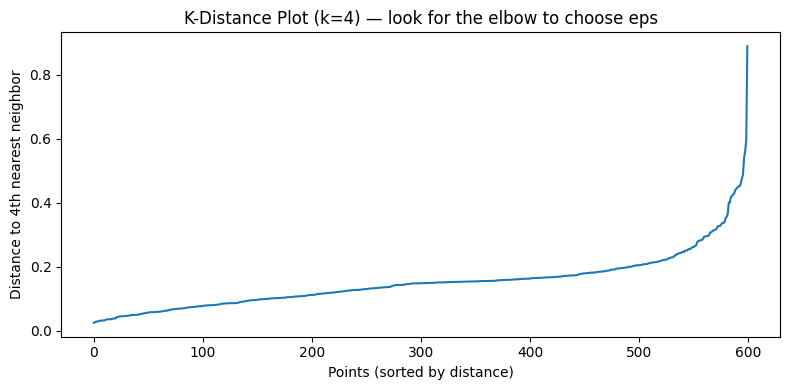


Plot saved to plots/dbscan_epsilon_plot.png
Look for the elbow and set EPS in the next cell.


In [4]:
# Rule of thumb: min_samples = max(5, n_features + 1)
min_samples = max(5, X.shape[1] + 1)
k = min_samples - 1
print(f"min_samples = {min_samples}, k = {k}")

# Fit NearestNeighbors to get distances to kth neighbor
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X)
distances, _ = nn.kneighbors(X)

# Take the farthest neighbor distance for each point, sorted ascending
kth_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(kth_distances)
plt.xlabel("Points (sorted by distance)")
plt.ylabel(f"Distance to {k}th nearest neighbor")
plt.title(f"K-Distance Plot (k={k}) — look for the elbow to choose eps")
plt.tight_layout()
plt.savefig("plots/dbscan_epsilon_plot.png", dpi=150)
plt.show()
plt.close()

print("\nPlot saved to plots/dbscan_epsilon_plot.png")
print("Look for the elbow and set EPS in the next cell.")

## 4. Fit DBSCAN

In [5]:
# Set eps based on the elbow in the k-distance plot above
# Adjust this value after inspecting the plot
EPS = 0.3

db = DBSCAN(eps=EPS, min_samples=min_samples)
df["cluster"] = db.fit_predict(X)

# Summary
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = (db.labels_ == -1).sum()

print(f"eps          = {EPS}")
print(f"min_samples  = {min_samples}")
print(f"Clusters found: {n_clusters}")
print(f"Noise points:   {n_noise} ({n_noise / len(df) * 100:.1f}% of data)")
print(f"\nCluster label counts:")
print(df["cluster"].value_counts().sort_index())

eps          = 0.3
min_samples  = 5
Clusters found: 4
Noise points:   23 (3.8% of data)

Cluster label counts:
cluster
-1     23
 0    119
 1    147
 2    171
 3    140
Name: count, dtype: int64


## 5. Noise Analysis

In [6]:
# Inspect the noise points — these are potential anomalies
df_noise = df[df["cluster"] == -1].copy()
df_clean = df[df["cluster"] != -1].copy()

print(f"Noise point statistics:")
print(df_noise[features].describe().round(2))

print(f"\nNon-noise statistics (for comparison):")
print(df_clean[features].describe().round(2))

Noise point statistics:
       recency_days  frequency  monetary_value
count         23.00      23.00           23.00
mean          80.57      11.91          261.37
std           66.12       8.31          189.23
min            2.00       1.00           60.14
25%           18.00       5.00           96.27
50%           66.00      10.00          203.36
75%          133.00      16.00          361.78
max          211.00      31.00          778.30

Non-noise statistics (for comparison):
       recency_days  frequency  monetary_value
count        577.00     577.00          577.00
mean          98.71       8.32          229.05
std          106.33       6.68          204.21
min            1.00       1.00            5.00
25%           16.00       3.00           60.73
50%           31.00       6.00          146.88
75%          141.00      14.00          445.68
max          365.00      26.00          708.52


## 6. Cluster Profiles

In [7]:
# Per-cluster mean — use df_clean (excluding noise) so stats aren't skewed
cluster_ids = sorted(df_clean["cluster"].unique())

print("Cluster profiles (mean):")
print(df_clean.groupby("cluster")[features].mean().round(2))

print(f"\nPoints per cluster:")
print(df_clean["cluster"].value_counts().sort_index())

Cluster profiles (mean):
         recency_days  frequency  monetary_value
cluster                                         
0              285.98       1.99           47.95
1              119.16       7.95          181.23
2               16.39      17.27          523.48
3               18.59       3.16           73.57

Points per cluster:
cluster
0    119
1    147
2    171
3    140
Name: count, dtype: int64


In [8]:
# ANOVA — which features differ most across clusters?
# Low p-value (<0.05) means the feature varies significantly across clusters
print("ANOVA — feature separation across clusters:")
for feature in features:
    groups = [df_clean.loc[df_clean["cluster"] == k, feature].values for k in cluster_ids]
    if len(groups) >= 2 and all(len(g) > 1 for g in groups):
        f_stat, p_val = f_oneway(*groups)
        significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        print(f"  {feature:20s}  F={f_stat:8.2f}  p={p_val:.4f}  {significance}")
    else:
        print(f"  {feature:20s}  (not enough groups for ANOVA)")

ANOVA — feature separation across clusters:
  recency_days          F= 5480.74  p=0.0000  ***
  frequency             F= 1207.94  p=0.0000  ***
  monetary_value        F= 2728.30  p=0.0000  ***


## 7. PCA Visualization

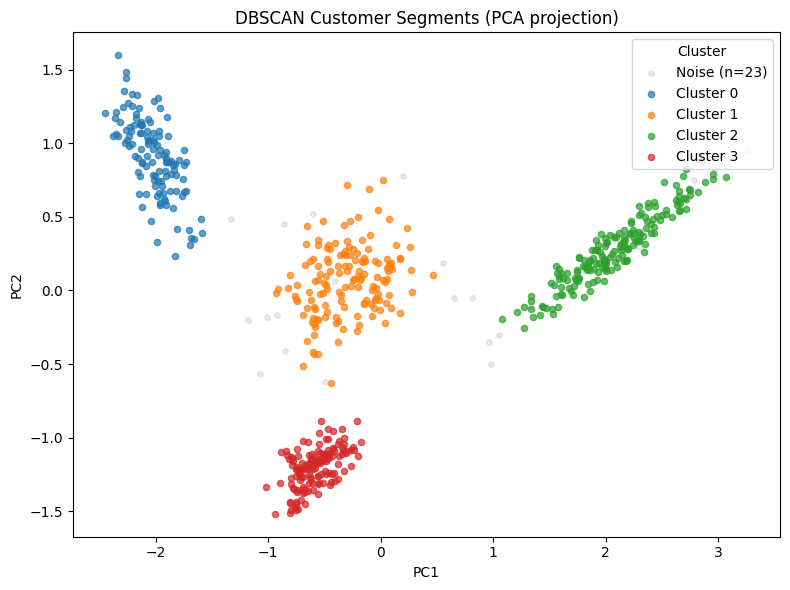

Plot saved to plots/dbscan_clusters_pca.png


In [9]:
# Project to 2D with PCA for visualization
X_2d = PCA(n_components=2).fit_transform(X)

mask_noise = df["cluster"] == -1
colors = plt.cm.tab10.colors  # discrete colors, one per cluster

plt.figure(figsize=(8, 6))

# Draw noise first (behind clusters)
plt.scatter(
    X_2d[mask_noise, 0], X_2d[mask_noise, 1],
    c="lightgray", s=15, alpha=0.5, label=f"Noise (n={n_noise})"
)

# Draw each cluster separately so legend entries are clean color swatches
for cid in cluster_ids:
    mask = df["cluster"] == cid
    plt.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        color=colors[cid % len(colors)], alpha=0.7, s=20, label=f"Cluster {cid}"
    )

plt.legend(loc="upper right", title="Cluster")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Customer Segments (PCA projection)")
plt.tight_layout()
plt.savefig("plots/dbscan_clusters_pca.png", dpi=150)
plt.show()
plt.close()

print("Plot saved to plots/dbscan_clusters_pca.png")

## 8. Label Assignment

Inspect the cluster profiles above and assign meaningful names.  
Update the `label_map` dictionary to match what you see in the data.

In [10]:
# After reviewing the cluster profiles, assign descriptive labels
# Adjust this map based on what the profiles show for your run
label_map = {
    0: "Champions",
    1: "At-Risk",
    2: "Promising",
    3: "Hibernating",
}

df_clean["segment"] = df_clean["cluster"].map(label_map).fillna("Hibernating")
df.loc[df["cluster"] != -1, "segment"] = df_clean["segment"]
df.loc[df["cluster"] == -1, "segment"] = "Anomaly"

print("Segment counts:")
print(df["segment"].value_counts())

print("\nSample output:")
df[["cluster", "segment"] + features].head(10)

Segment counts:
segment
Promising      171
At-Risk        147
Hibernating    140
Champions      119
Anomaly         23
Name: count, dtype: int64

Sample output:


,cluster,segment,recency_days,frequency,monetary_value
0,0,Champions,272,2,60.44
1,1,At-Risk,128,7,198.06
2,1,At-Risk,86,8,201.47
3,0,Champions,245,2,42.82
4,2,Promising,23,17,358.56
5,-1,Anomaly,18,7,467.34
6,3,Hibernating,27,3,38.19
7,1,At-Risk,109,7,105.56
8,3,Hibernating,27,4,69.67
9,0,Champions,292,2,12.52
